<a href="https://colab.research.google.com/github/Saiful-2/forest-cover-classification/blob/main/notebooks/6_forest_confusion_matrix.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Confusion Matrix Visualization for Forest Cover Type Classification**
STEP 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import confusion_matrix, classification_report

## STEP 2: Load Dataset

In [2]:
url = "https://raw.githubusercontent.com/Saiful-2/datasets/main/forest_cleaned_dataset.csv"
df = pd.read_csv(url)
df.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type,Soil_Sum
0,3351,206,27,726,124,3813,192,252,180,2271,...,0,0,0,0,0,1,0,0,1,1
1,2732,129,7,212,1,1082,231,236,137,912,...,0,0,0,0,0,0,0,0,2,1
2,2572,24,9,201,25,957,216,222,142,2191,...,0,0,0,0,0,0,0,0,2,1
3,2824,69,13,417,39,3223,233,214,110,6478,...,0,0,0,0,0,0,0,0,2,1
4,2529,84,5,120,9,1092,227,231,139,4983,...,0,0,0,0,0,0,0,0,2,1


## STEP 3: Prepare Data

In [3]:
X = df.drop('Cover_Type', axis=1)
y = df['Cover_Type']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## STEP 4: Scaling

In [4]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## STEP 5: Train Model
best-performing model → usually
👉 Random Forest

In [5]:
model = RandomForestClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

## STEP 6: Create Confusion Matrix

In [6]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[3137,  481,    1,    0,    1,    0,   10],
       [ 366, 4344,   30,    0,    5,    9,    2],
       [   0,   25,  385,    0,    1,   17,    0],
       [   0,    0,    7,    4,    0,    1,    0],
       [   5,   86,    2,    0,   57,    1,    0],
       [   0,   31,   35,    0,    0,  167,    0],
       [  64,    2,    0,    0,    0,    0,  262]])

## STEP 7: Visualize Confusion Matrix (MAIN PART 🔥)

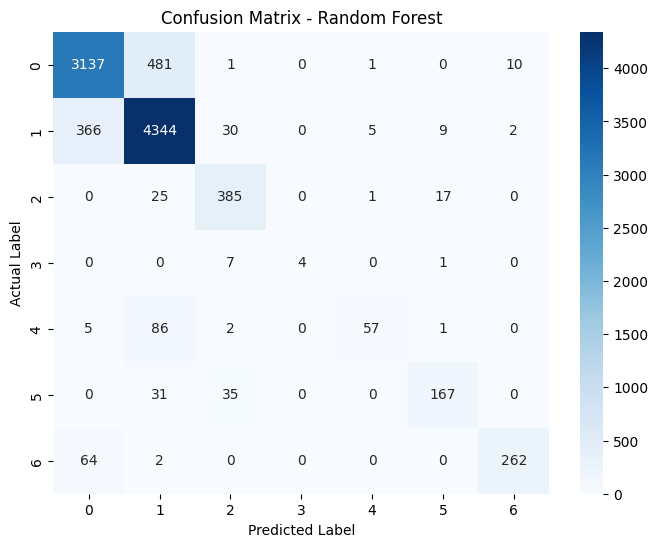

In [7]:
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Random Forest")

plt.show()

## STEP 8: Add Class Labels (PRO LEVEL 🔥)

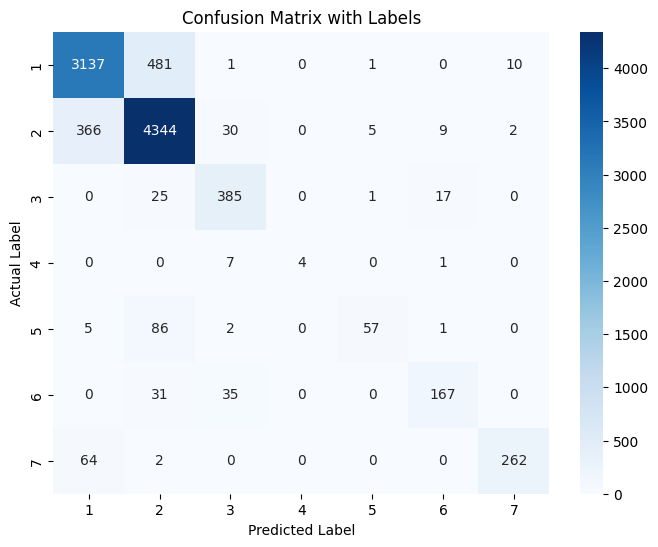

In [8]:
labels = sorted(y.unique())

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix with Labels")

plt.show()

## STEP 9: Classification Report

In [9]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.88      0.86      0.87      3630
           2       0.87      0.91      0.89      4756
           3       0.84      0.90      0.87       428
           4       1.00      0.33      0.50        12
           5       0.89      0.38      0.53       151
           6       0.86      0.72      0.78       233
           7       0.96      0.80      0.87       328

    accuracy                           0.88      9538
   macro avg       0.90      0.70      0.76      9538
weighted avg       0.88      0.88      0.87      9538



## STEP 10. MULTI-MODEL COMPARISON

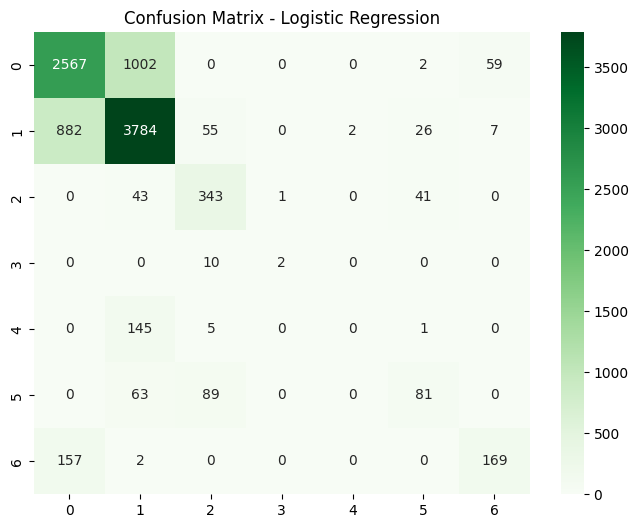

In [10]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(8,6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

## STEP 11: INSIGHTS
###🌲 Forest Cover Type – Key Insights:

Elevation is the most important feature influencing forest cover type.

Environmental factors like hillshade, slope, and distance to water/roads significantly affect predictions.

The dataset is imbalanced, so the model performs better on dominant classes.

The confusion matrix shows strong performance overall, with high correct predictions (diagonal values).

Misclassification occurs between similar forest types, indicating overlapping ecological conditions.

Soil type and wilderness area features add value but increase feature complexity.